# 🧹 Pandas Data Cleaning & EDA

**Goal:** take a messy sales dataset, clean it step by step, then explore it.

> 💡 Real-world data is always messy. Before any analysis or ML model, you must clean it.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

## Step 1: Load the data and take a first look

Always inspect first: `head()` shows sample rows, `info()` reveals missing values **and** wrong data types.

In [2]:
df = pd.read_csv("data/sales_data.csv")

print("=== First 5 rows ===")
print(df.head())
print("\n=== Shape (rows, columns):", df.shape)
print("\n=== Info (check missing values + dtypes) ===")
df.info()

=== First 5 rows ===
   OrderID        Date        City     Product  Quantity     Price Salesperson
0     1001  2026-06-13         NaN  Headphones       3.0      8000       Usman
1     1002  2026-01-23  faisalabad     Monitor      10.0  Rs.35000       Usman
2     1003  2026-04-18    Peshawar  Headphones       1.0      8000      Fatima
3     1004  2026-03-29     QUETTA        Mouse       2.0      2500       Bilal
4     1005  2026-01-12  Rawalpindi      Webcam       5.0      6500       Bilal

=== Shape (rows, columns): (510, 7)

=== Info (check missing values + dtypes) ===
<class 'pandas.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OrderID      510 non-null    int64  
 1   Date         510 non-null    str    
 2   City         503 non-null    str    
 3   Product      510 non-null    str    
 4   Quantity     491 non-null    float64
 5   Price        510 non-null    s

## Step 2: Handle missing values

- **Quantity** (2 missing): fill with **median** — safer than mean, one huge order won't skew it.
- **City** (1 missing): we can't guess a city → drop that row.
- **Salesperson** (3 missing): label "Unknown" — dropping would lose real sales records.

In [3]:
print("=== Missing values per column ===")
print(df.isnull().sum())

df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df = df.dropna(subset=["City"])
df["Salesperson"] = df["Salesperson"].fillna("Unknown")

print("\n=== After handling ===")
print(df.isnull().sum())

=== Missing values per column ===
OrderID         0
Date            0
City            7
Product         0
Quantity       19
Price           0
Salesperson    33
dtype: int64

=== After handling ===
OrderID        0
Date           0
City           0
Product        0
Quantity       0
Price          0
Salesperson    0
dtype: int64


## Step 3: Remove duplicate rows

⚠️ **Kuch orders ki duplicate entries hain** — same order do dafa count ho to sales numbers inflate ho jayenge. Neeche dekho kaunsi IDs duplicate hain!

In [4]:
dup_ids = df[df.duplicated(keep=False)]["OrderID"].unique()
print("Duplicated OrderIDs:", sorted(dup_ids))

before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate row(s)")

Duplicated OrderIDs: [np.int64(1014), np.int64(1033), np.int64(1156), np.int64(1218), np.int64(1222), np.int64(1250), np.int64(1294), np.int64(1309), np.int64(1415), np.int64(1461)]
Removed 10 duplicate row(s)


## Step 4: Fix inconsistent text (City column)

`"Lahore"`, `"lahore"`, `"LAHORE "` are the **same** city — but for `groupby()` they are 3 different groups!
Fix: `strip()` removes extra spaces, `title()` standardizes to `"Lahore"` format.

In [5]:
print("=== City values BEFORE ===")
print(df["City"].unique())

df["City"] = df["City"].str.strip().str.title()

print("\n=== City values AFTER ===")
print(df["City"].unique())

=== City values BEFORE ===
<StringArray>
['faisalabad',   'Peshawar',    'QUETTA ', 'Rawalpindi',     'Quetta',
  'Islamabad',     'Multan',     'MULTAN', 'rawalpindi', 'Faisalabad',
     'lahore',   'peshawar',     'Lahore', 'RAWALPINDI',    ' lahore',
    'Karachi',   'Karachi ',   'PESHAWAR', 'FAISALABAD',     'quetta',
  'islamabad',    'karachi',     'multan',    'Lahore ',     'LAHORE',
    'KARACHI',  'ISLAMABAD']
Length: 27, dtype: str

=== City values AFTER ===
<StringArray>
['Faisalabad',   'Peshawar',     'Quetta', 'Rawalpindi',  'Islamabad',
     'Multan',     'Lahore',    'Karachi']
Length: 8, dtype: str


## Step 5: Fix wrong data types (Price column)

Some prices are `"Rs.35000"` (text) — math on text fails. Strip `"Rs."` and convert to numbers.
Also convert `Date` to datetime so we can analyze trends by month.

In [6]:
df["Price"] = (
    df["Price"].astype(str)
    .str.replace("Rs.", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["Date"] = pd.to_datetime(df["Date"])
df["Revenue"] = df["Quantity"] * df["Price"]

print("=== Cleaned dtypes ===")
print(df.dtypes)

=== Cleaned dtypes ===
OrderID                 int64
Date           datetime64[us]
City                      str
Product                   str
Quantity              float64
Price                 float64
Salesperson               str
Revenue               float64
dtype: object


## Step 6: Explore the clean data (EDA)

Now the fun part — ask questions: which city earns most? Which product? Any monthly trend?

In [7]:
print("=== Summary stats ===")
print(df.describe())

print("\n=== Total revenue by city ===")
print(df.groupby("City")["Revenue"].sum().sort_values(ascending=False))

print("\n=== Total revenue by product ===")
print(df.groupby("Product")["Revenue"].sum().sort_values(ascending=False))

print("\n=== Monthly revenue trend ===")
print(df.set_index("Date").resample("ME")["Revenue"].sum())

=== Summary stats ===
           OrderID                        Date    Quantity          Price  \
count   493.000000                         493  493.000000     493.000000   
mean   1250.965517  2026-04-01 13:46:36.754564    5.511156   29794.117647   
min    1002.000000         2026-01-01 00:00:00    1.000000    2500.000000   
25%    1126.000000         2026-02-15 00:00:00    3.000000    6500.000000   
50%    1252.000000         2026-03-31 00:00:00    5.000000   12000.000000   
75%    1375.000000         2026-05-17 00:00:00    8.000000   28000.000000   
max    1500.000000         2026-06-30 00:00:00   10.000000  150000.000000   
std     144.467078                         NaN    2.971131   45283.835056   

            Revenue  
count  4.930000e+02  
mean   1.651166e+05  
min    2.500000e+03  
25%    2.250000e+04  
50%    5.200000e+04  
75%    1.400000e+05  
max    1.500000e+06  
std    2.947009e+05  

=== Total revenue by city ===
City
Faisalabad    13689500.0
Rawalpindi    11339000.0


## Step 7: Visualize 📊

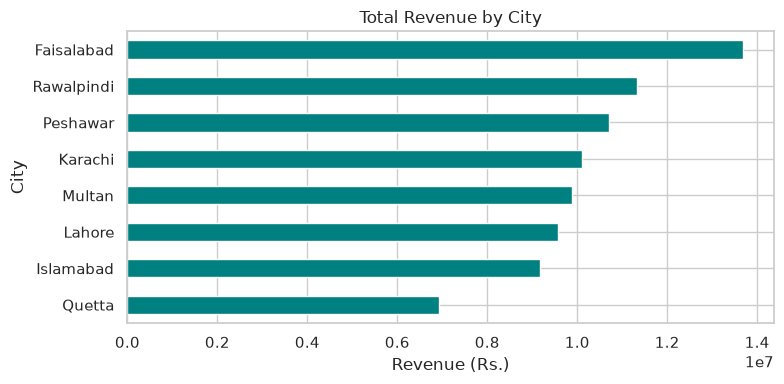

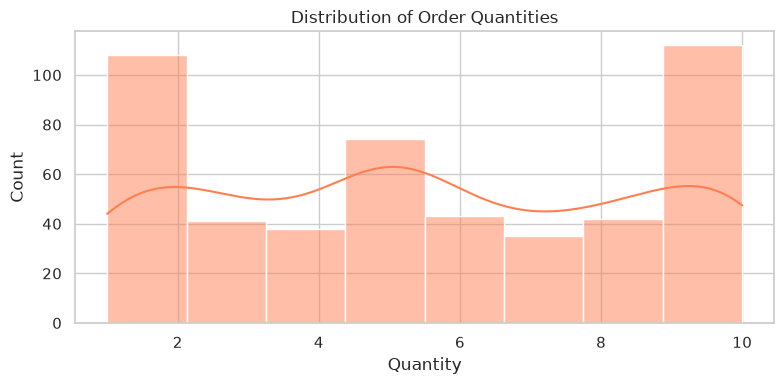

In [8]:
plt.figure(figsize=(8, 4))
df.groupby("City")["Revenue"].sum().sort_values().plot(kind="barh", color="teal")
plt.title("Total Revenue by City")
plt.xlabel("Revenue (Rs.)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df["Quantity"], bins=8, kde=True, color="coral")
plt.title("Distribution of Order Quantities")
plt.xlabel("Quantity")
plt.tight_layout()
plt.show()

## Step 8: Save the cleaned dataset ✅

Compare `data/sales_data.csv` (messy) vs `data/sales_data_cleaned.csv` (clean)!

In [9]:
df.to_csv("data/sales_data_cleaned.csv", index=False)
print("Saved: data/sales_data_cleaned.csv")
print("\nDone! 🎉")

Saved: data/sales_data_cleaned.csv

Done! 🎉
